# Sharpe-Hacking — can you *fake* a great risk-adjusted return? 🎛️
### Juicing a strategy's headline Sharpe with pure financial engineering, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Can_engineering_fake_a_Sharpe%3F: Confirmed](https://img.shields.io/badge/Can_engineering_fake_a_Sharpe%3F-Confirmed-8b949e?style=flat-square)

The **Sharpe ratio** is the single most quoted number in investing: return per unit of risk. A Sharpe of 2 with a smooth, steadily-rising equity curve is catnip to allocators. It is also, it turns out, one of the *easiest numbers in finance to fake* — not by lying, but by pure **financial engineering**: how you *report* and *reshape* your returns.

So we run the experiment on a stream of returns we **built to have no real edge** — a modest, honest Sharpe and zero skill — and try three classic tricks: **smoothing** the returns (like an illiquid fund with stale prices), piling on **leverage**, and **volatility targeting**. Which ones actually 'work'? And do any of them add real money?

> 📓 **This is the plain-language layer.** Want the autocorrelation-corrected Sharpe, the bootstrap bands and the maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it, on a deterministic synthetic tape. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sharpe_hacking import data, strategy as st

# The whole demo runs on the deterministic, offline seed-590 null tape (honest Sharpe ~0.24, ZERO
# alpha). This is a synthetic-only method demo — there is no real-tape cell by design.
RET, TRUTH = data.synthetic_series(n_days=3000, alpha=0.0, seed=590)
print("null tape:", len(RET), "days,", RET.index[0].date(), "->", RET.index[-1].date(),
      "| honest Sharpe %.2f, alpha %.0f (fp %s)" % (
          st.sharpe_honest_annual(RET.to_numpy()), TRUTH.alpha, data.fingerprint(RET)))


null tape: 3000 days, 2008-01-02 -> 2019-07-02 | honest Sharpe 0.24, alpha 0 (fp 807d5cddc33f)


## The answer first 🎯

| Question | Answer |
|---|---|
| Can *smoothing* your returns fake a great Sharpe? | **Yes — hugely.** It lifts the *reported* Sharpe from **0.323** to **0.559** (+73%), and up to **0.979** (3× !) if you smooth harder — with **zero** added return. |
| Does piling on *leverage* help? | **No — not at all.** 3× leverage leaves the Sharpe *exactly* unchanged (0.323). It buys you a wilder ride, not a better ratio. |
| Is *volatility targeting* magic? | **No.** On this tape it *lowered* the Sharpe (to **0.158**). It's a real technique, but no free lunch. |
| Is any of the 'gain' real? | **None of it.** An honest Sharpe that can't be fooled by smoothing stays put at **~0.24** through all three tricks. |

> The smooth, high-Sharpe track record everyone loves is often the *warning sign*, not the boast — it's exactly what stale, illiquid marks produce for free.

## 1 · The claim

> *"You can juice a strategy's Sharpe ratio with pure financial engineering — vol-targeting, leverage, smoothing — without adding any real edge."*

The Sharpe ratio is (roughly) your average return divided by how much it wobbles, scaled to a year. Two ways to make it bigger: earn more (hard, requires real skill), or **wobble less** (easy, if you're willing to *report* your returns cleverly). This study is about the second path — the metric-gaming one — and whether the folk levers people reach for actually move the needle.

## 2 · So what?

Because allocators hand out billions on the strength of a Sharpe ratio. If a smooth, Sharpe-2 line can be *manufactured* from a mediocre, no-edge return stream, then the number is nearly worthless without knowing *how it was measured*. The desk has already shown you can fake a Sharpe by **searching** for a lucky backtest ([344 Backtest-Overfitting](../../344-backtest-overfitting/), [589 Genetic-Algo-Overfit](../../589-genetic-algo-overfit/)); here we fake it a different way — by **reshaping how the returns are reported**.

## 3 · How would we even know?

We need a return stream we *know* has no real edge, so any Sharpe 'improvement' must be fake. So we **build** one: 3,000 days of returns with a modest honest Sharpe (~0.24) and zero skill, but with realistic *volatility clustering* (calm stretches and stormy stretches) so the vol-targeting trick has something real to act on.

Then we run three tricks and, crucially, measure the Sharpe **two ways**:

1. the **naive** Sharpe everyone quotes (average ÷ wobble × √252), and
2. an **honest** Sharpe that corrects for a trap: if your returns are artificially *smooth* (each day looks like yesterday), the naive formula over-counts your skill. The honest version undoes exactly that.

If a trick only moves the *naive* number and not the *honest* one, it's a fake.

## 4 · The teardown — let's actually try it

**Trick #1 — smoothing.** Pretend you run an illiquid fund that marks its book slowly, so each reported return is a blend of today's and yesterday's. Watch the *reported* Sharpe jump while the honest one doesn't move.

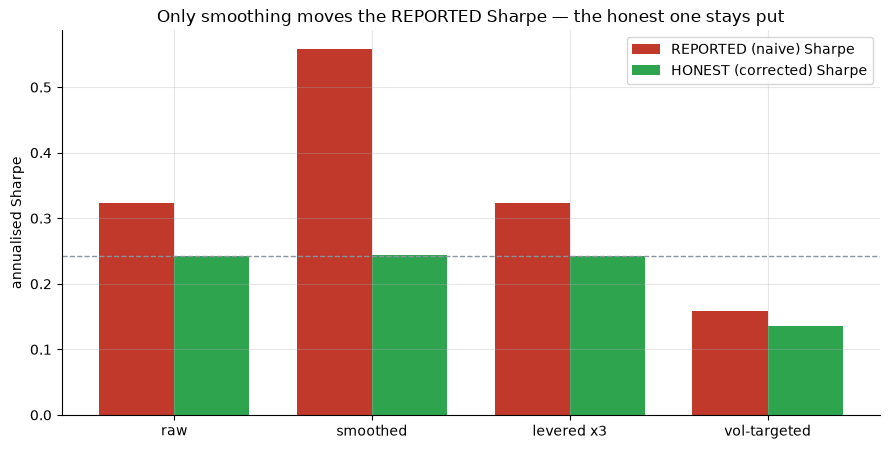

raw            reported 0.323 | honest 0.242
smoothed       reported 0.559 | honest 0.244
levered x3     reported 0.323 | honest 0.242
vol-targeted   reported 0.158 | honest 0.136


In [2]:
r = RET.to_numpy()
gt = st.gaming_table(r, theta=0.5, leverage=3.0, target_ann_vol=0.10)
labels = ['raw', 'smoothed', 'levered x3', 'vol-targeted']
naive = gt['naive_sharpe'].values; honest = gt['honest_sharpe'].values
x = np.arange(len(labels)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.bar(x - w/2, naive, w, color=RED, label='REPORTED (naive) Sharpe')
ax.bar(x + w/2, honest, w, color=GREEN, label='HONEST (corrected) Sharpe')
ax.axhline(honest[0], ls='--', c=GREY, lw=1)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel('annualised Sharpe')
ax.set_title('Only smoothing moves the REPORTED Sharpe — the honest one stays put')
ax.legend(); plt.tight_layout(); plt.show()
for lab, nn, hh in zip(labels, naive, honest):
    print(f'{lab:14s} reported {nn:.3f} | honest {hh:.3f}')

There it is. **Smoothing** lifts the reported Sharpe from **0.323** to **0.559** — a +73% 'improvement' that added *nothing* (the honest Sharpe stays ~0.24). **Leverage** does *literally nothing* to either number — the bars are identical to raw. **Vol-targeting** actually *lowered* the Sharpe here. The only 'winner' is the pure accounting trick.

**How far can smoothing take you?** The more you smooth (higher θ = staler marks), the prettier the reported number — while the honest Sharpe flatlines:

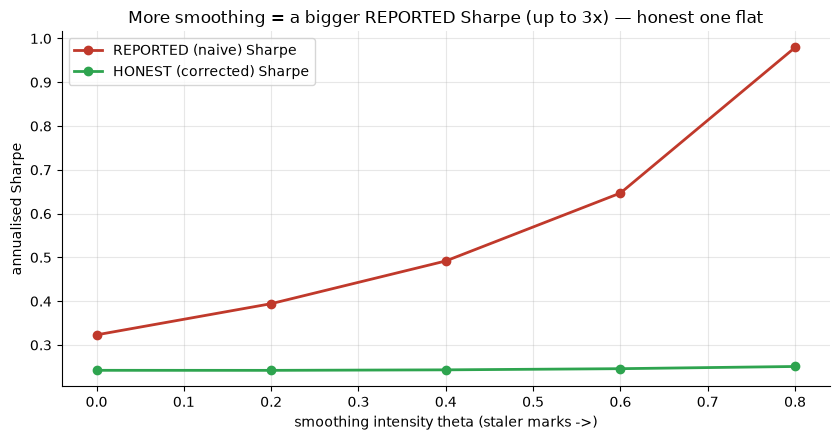

       naive_sharpe  honest_sharpe  lag1_autocorr
theta                                            
0.0           0.323          0.242          0.011
0.2           0.394          0.242          0.215
0.4           0.492          0.243          0.415
0.6           0.647          0.246          0.614
0.8           0.979          0.251          0.809


In [3]:
sw = st.theta_sweep(r, thetas=(0.0, 0.2, 0.4, 0.6, 0.8))
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(sw.index, sw['naive_sharpe'], 'o-', c=RED, lw=2, label='REPORTED (naive) Sharpe')
ax.plot(sw.index, sw['honest_sharpe'], 'o-', c=GREEN, lw=2, label='HONEST (corrected) Sharpe')
ax.set_xlabel('smoothing intensity theta (staler marks ->)'); ax.set_ylabel('annualised Sharpe')
ax.set_title('More smoothing = a bigger REPORTED Sharpe (up to 3x) — honest one flat')
ax.legend(); plt.tight_layout(); plt.show()
print(sw.round(3).to_string())

At heavy smoothing (θ 0.8) the reported Sharpe hits **0.979** — three times the truth — purely because the returns now look artificially calm (each day tracks the last, autocorrelation 0.01 → 0.81). This is exactly why a suspiciously *smooth* hedge-fund track record should raise an eyebrow, not a cheque.

## 5 · The verdict

- **Signal — None.** On a stream with no real edge, the only Sharpe 'gain' is a measurement illusion (smoothing); leverage does nothing, vol-targeting hurts. Nothing real to detect.
- **Tradability — Mirage.** A smoothed Sharpe is an accounting number you can't spend. There's no money in any of it.
- **Can engineering fake a Sharpe? — Confirmed.** Yes — the *reported* one, by up to 3×. Only the honest, correction-proof Sharpe tells the truth.

## 6 · Could you actually 'trade' it?

You can't spend a Sharpe ratio. Smoothing just changes the *story* your returns tell — the actual dollars are unchanged (worse, the smoothing hides the real drawdowns until they arrive all at once). Leverage genuinely changes your dollars, but scales risk and reward together — the ratio is fixed. Vol-targeting trades every day and, here, loses after costs. There is no free Sharpe to harvest — only a prettier report.

## 7 · Going further 🚪

- **The searching cousins.** [344 Backtest-Overfitting](../../344-backtest-overfitting/) and [589 Genetic-Algo-Overfit](../../589-genetic-algo-overfit/) fake a Sharpe by *trying many strategies* and keeping the luckiest; this study fakes it by *reshaping the returns*.
- **The fix is public.** The autocorrelation-corrected Sharpe (Lo 2002; Getmansky-Lo-Makarov 2004) undoes the smoothing game — see the quants notebook.

*Think a smooth, high-Sharpe track record proves skill? Fork this, feed in a real illiquid-fund return series, and watch the correction cut the Sharpe down to size.*